In [1]:
# import libraries and other configurations
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import warnings
import dython
from scipy import stats
from dython.nominal import associations

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

sns.set_theme(style="whitegrid")

warnings.filterwarnings("ignore")

RANDOM_STATE = 121

In [2]:
# Load cleaned dataset
df = pd.read_csv(
    "../data/processed/cleaned_donor_data.csv",
)

df.columns.tolist()

['donor_unique_id',
 'donor_postal_code',
 'donor_age',
 'gender_identity',
 'is_member_flag',
 'is_alumnus_flag',
 'is_parent_flag',
 'has_involvement_flag',
 'preferred_address_type',
 'has_email_flag',
 'consecutive_donor_years',
 'last_fiscal_year_donation',
 'donation_2_fiscal_years_ago',
 'donation_3_fiscal_years_ago',
 'donation_4_fiscal_years_ago',
 'donation_5_fiscal_years_ago',
 'current_fiscal_year_donation',
 'cumulative_donation_amount',
 'donor_indicator_flag']

In [3]:
# Verify dataset loaded correctly
print(f"Dataset Shape: {df.shape}")
df.sample(10, random_state=RANDOM_STATE)

Dataset Shape: (34403, 19)


,donor_unique_id,donor_postal_code,donor_age,gender_identity,is_member_flag,is_alumnus_flag,is_parent_flag,has_involvement_flag,preferred_address_type,has_email_flag,consecutive_donor_years,last_fiscal_year_donation,donation_2_fiscal_years_ago,donation_3_fiscal_years_ago,donation_4_fiscal_years_ago,donation_5_fiscal_years_ago,current_fiscal_year_donation,cumulative_donation_amount,donor_indicator_flag
33267,33371,42301.0,46,Female,0,0,0,0,Home,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
26595,26683,45620.0,42,Female,0,0,0,0,Home,0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
16653,16704,33427.0,28,Female,0,0,0,0,Home,0,0,0.0,120.0,0.0,0.0,0.0,0.0,120.0,1
21428,21498,54131.0,33,Female,0,0,0,0,Home,0,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1
16873,16924,90265.0,33,Male,0,1,0,0,Home,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
19919,19982,54459.0,32,Female,0,0,0,0,Home,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
15478,15527,64686.0,42,Male,0,0,0,0,Home,0,8,0.0,0.0,10.0,0.0,0.0,0.0,9680.0,1
591,596,12067.0,42,Female,0,0,1,0,Home,0,0,0.0,100.0,1.0,0.0,0.0,0.0,101.0,1
1474,1483,90265.0,42,Female,0,1,0,0,Home,1,0,0.0,0.0,0.0,0.0,0.0,0.0,479.0,1
22846,22922,45856.0,36,Female,0,0,0,0,Home,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [4]:
# Verify dataset data types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 34403 entries, 0 to 34402
Data columns (total 19 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   donor_unique_id               34403 non-null  int64  
 1   donor_postal_code             34312 non-null  float64
 2   donor_age                     34403 non-null  int64  
 3   gender_identity               33912 non-null  str    
 4   is_member_flag                34403 non-null  int64  
 5   is_alumnus_flag               34403 non-null  int64  
 6   is_parent_flag                34403 non-null  int64  
 7   has_involvement_flag          34403 non-null  int64  
 8   preferred_address_type        30370 non-null  str    
 9   has_email_flag                34403 non-null  int64  
 10  consecutive_donor_years       34403 non-null  int64  
 11  last_fiscal_year_donation     34403 non-null  float64
 12  donation_2_fiscal_years_ago   34403 non-null  float64
 13  donation_3_f

In [5]:
# Data types summary
dtype_summary = (
    df.dtypes
      .astype(str)
      .value_counts()
      .reset_index()
      .style.hide(axis="index")
)

dtype_summary.columns = ["Data Type", "Count"]
dtype_summary

index,count
int64,9
float64,8
str,2


In [6]:
# Verify dataset missing values
missing_summary = (
    df.isna()
      .sum()
      .to_frame("Missing Count")
)

missing_summary["Missing %"] = (
    missing_summary["Missing Count"] / len(df) * 100
)

missing_summary = (
    missing_summary
      .sort_values("Missing Count", ascending=False)
)

missing_summary

,Missing Count,Missing %
preferred_address_type,4033,11.722815
gender_identity,491,1.427201
donor_postal_code,91,0.264512
donor_unique_id,0,0.000000
last_fiscal_year_donation,0,0.000000
cumulative_donation_amount,0,0.000000
current_fiscal_year_donation,0,0.000000
donation_5_fiscal_years_ago,0,0.000000
donation_4_fiscal_years_ago,0,0.000000
donation_3_fiscal_years_ago,0,0.000000


## Dataset Overview

The finalized cleaned analytical dataset was successfully loaded and verified for Dython analysis. The dataset contains **34,403 donor records** and **19 features**, consistent with the dataset used throughout Phase 2. Data types and missing values match expectations from the data cleaning process, and all required libraries were successfully imported. The environment is now prepared for mixed-type association analysis.

In [7]:
# Define feature groups
numeric_features = [
    "donor_age",
    "consecutive_donor_years",
    "last_fiscal_year_donation",
    "donation_2_fiscal_years_ago",
    "donation_3_fiscal_years_ago",
    "donation_4_fiscal_years_ago",
    "donation_5_fiscal_years_ago",
    "current_fiscal_year_donation",
    "cumulative_donation_amount"
]

categorical_features = [
    "gender_identity",
    "preferred_address_type"
]

binary_features = [
    "is_alumnus_flag",
    "is_parent_flag",
    "has_involvement_flag",
    "has_email_flag"
]

target_feature = [
    "donor_indicator_flag"
]

In [8]:
# Variable classification summary
association_features = (
    numeric_features
    + categorical_features
    + binary_features
    + target_feature
)

variable_summary = pd.DataFrame({
    "Variable": association_features,
    "Category": (
        ["Numeric"] * len(numeric_features)
        + ["Categorical"] * len(categorical_features)
        + ["Binary"] * len(binary_features)
        + ["Target"]
    )
})

variable_summary.style.hide(axis="index")

Variable,Category
donor_age,Numeric
consecutive_donor_years,Numeric
last_fiscal_year_donation,Numeric
donation_2_fiscal_years_ago,Numeric
donation_3_fiscal_years_ago,Numeric
donation_4_fiscal_years_ago,Numeric
donation_5_fiscal_years_ago,Numeric
current_fiscal_year_donation,Numeric
cumulative_donation_amount,Numeric
gender_identity,Categorical


In [9]:
# Verify selected features exist in the dataset
missing_features = [col for col in association_features if col not in df.columns]

if missing_features:
    print("Missing features:")
    print(missing_features)
else:
    print("All selected features are present in the dataset.")

All selected features are present in the dataset.


In [10]:
# Create analysis dataset for dython analysis
association_df = df[association_features].copy()

print(f"Association Dataset Shape: {association_df.shape}")

association_df.sample(10, random_state=RANDOM_STATE)

Association Dataset Shape: (34403, 16)


,donor_age,consecutive_donor_years,last_fiscal_year_donation,donation_2_fiscal_years_ago,donation_3_fiscal_years_ago,donation_4_fiscal_years_ago,donation_5_fiscal_years_ago,current_fiscal_year_donation,cumulative_donation_amount,gender_identity,preferred_address_type,is_alumnus_flag,is_parent_flag,has_involvement_flag,has_email_flag,donor_indicator_flag
33267,46,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Female,Home,0,0,0,0,0
26595,42,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Female,Home,0,0,0,0,0
16653,28,0,0.0,120.0,0.0,0.0,0.0,0.0,120.0,Female,Home,0,0,0,0,1
21428,33,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,Female,Home,0,0,0,0,1
16873,33,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Male,Home,1,0,0,0,0
19919,32,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Female,Home,0,0,0,0,0
15478,42,8,0.0,0.0,10.0,0.0,0.0,0.0,9680.0,Male,Home,0,0,0,0,1
591,42,0,0.0,100.0,1.0,0.0,0.0,0.0,101.0,Female,Home,0,1,0,0,1
1474,42,0,0.0,0.0,0.0,0.0,0.0,0.0,479.0,Female,Home,1,0,0,1,1
22846,36,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Female,Home,0,0,0,0,0


In [11]:
# Verify analysis dataset
association_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 34403 entries, 0 to 34402
Data columns (total 16 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   donor_age                     34403 non-null  int64  
 1   consecutive_donor_years       34403 non-null  int64  
 2   last_fiscal_year_donation     34403 non-null  float64
 3   donation_2_fiscal_years_ago   34403 non-null  float64
 4   donation_3_fiscal_years_ago   34403 non-null  float64
 5   donation_4_fiscal_years_ago   34403 non-null  float64
 6   donation_5_fiscal_years_ago   34403 non-null  float64
 7   current_fiscal_year_donation  34403 non-null  float64
 8   cumulative_donation_amount    34403 non-null  float64
 9   gender_identity               33912 non-null  str    
 10  preferred_address_type        30370 non-null  str    
 11  is_alumnus_flag               34403 non-null  int64  
 12  is_parent_flag                34403 non-null  int64  
 13  has_involvem

In [12]:
# Verify analysis dataset
association_df.nunique().sort_values()

is_alumnus_flag                    2
is_parent_flag                     2
has_involvement_flag               2
has_email_flag                     2
donor_indicator_flag               2
gender_identity                    3
preferred_address_type             4
consecutive_donor_years           33
donor_age                         88
current_fiscal_year_donation     165
donation_4_fiscal_years_ago      177
donation_5_fiscal_years_ago      182
last_fiscal_year_donation        188
donation_3_fiscal_years_ago      188
donation_2_fiscal_years_ago      189
cumulative_donation_amount      1592
dtype: int64

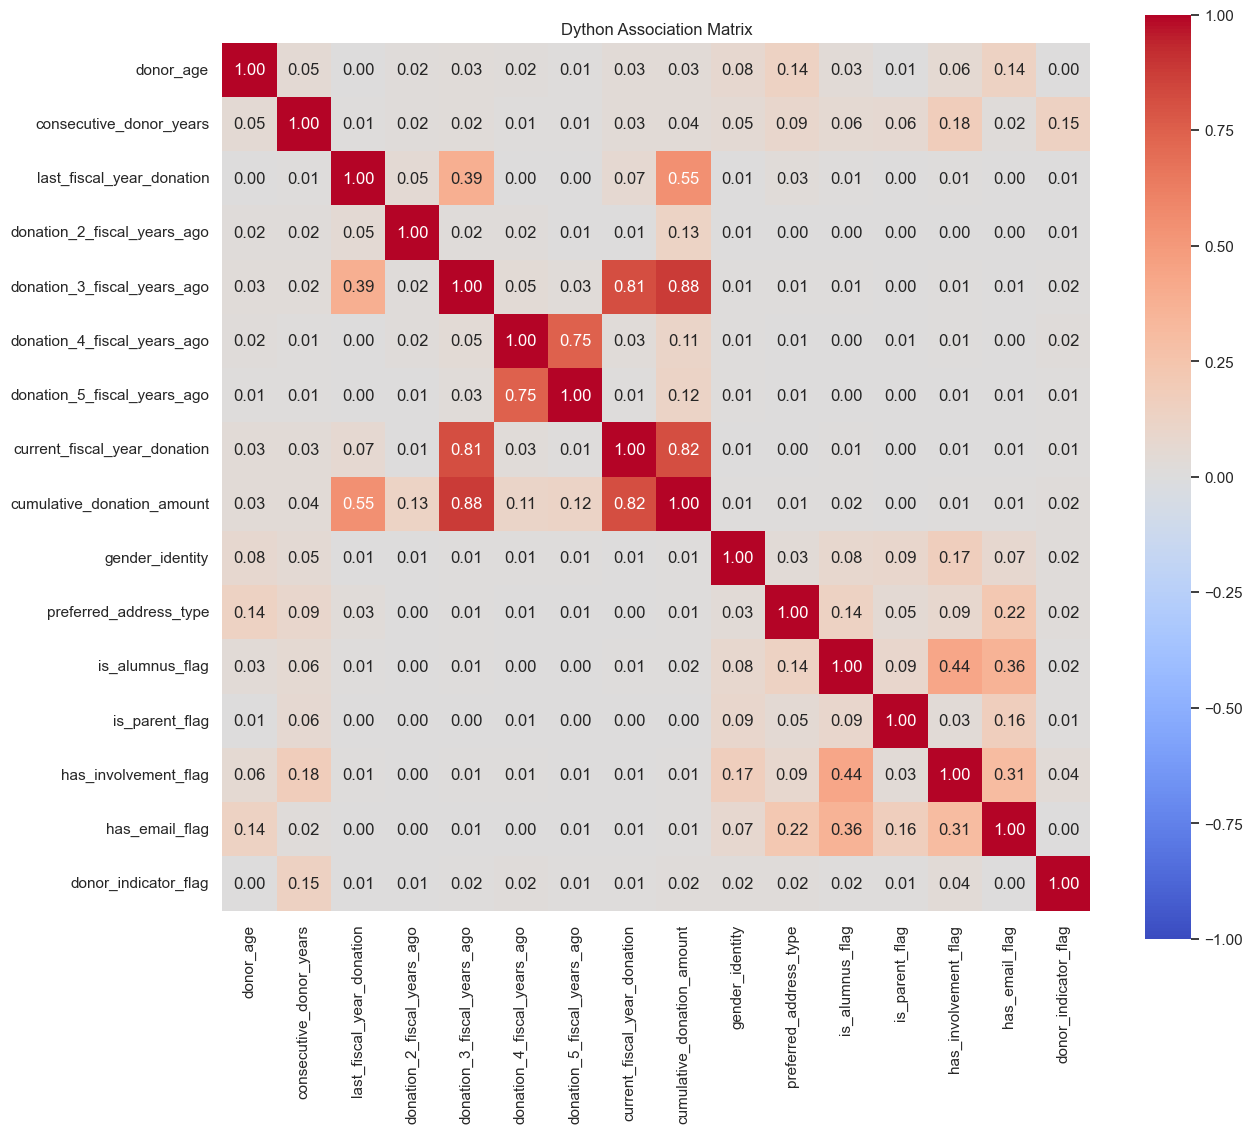

In [13]:
# Create Dython association matrix
association_results = associations(
    association_df,
    nominal_columns=categorical_features + binary_features + target_feature,
    figsize=(14, 12),
    cmap="coolwarm",
    title="Dython Association Matrix",
    clustering=False,
    nan_strategy="replace",
    nan_replace_value="Missing"
)

In [14]:
# Display the correlation matrix
association_matrix = association_results["corr"]

association_matrix

,donor_age,consecutive_donor_years,last_fiscal_year_donation,donation_2_fiscal_years_ago,donation_3_fiscal_years_ago,donation_4_fiscal_years_ago,donation_5_fiscal_years_ago,current_fiscal_year_donation,cumulative_donation_amount,gender_identity,preferred_address_type,is_alumnus_flag,is_parent_flag,has_involvement_flag,has_email_flag,donor_indicator_flag
donor_age,1.000000,0.049618,0.002854,0.021981,0.028051,0.016955,0.013613,0.032794,0.031465,0.076968,0.135177,0.033379,0.006013,0.061315,0.135970,0.001757
consecutive_donor_years,0.049618,1.000000,0.011967,0.016613,0.024178,0.012232,0.014793,0.032918,0.039034,0.053278,0.092522,0.058656,0.063570,0.178617,0.017178,0.147963
last_fiscal_year_donation,0.002854,0.011967,1.000000,0.050901,0.388045,0.004393,0.002278,0.070240,0.546359,0.006280,0.031228,0.010270,0.001717,0.009882,0.004361,0.005465
donation_2_fiscal_years_ago,0.021981,0.016613,0.050901,1.000000,0.021612,0.017216,0.006616,0.007489,0.129662,0.005173,0.002851,0.003315,0.000781,0.003404,0.003699,0.007196
donation_3_fiscal_years_ago,0.028051,0.024178,0.388045,0.021612,1.000000,0.045495,0.026824,0.814676,0.875629,0.008428,0.008988,0.012031,0.000461,0.007955,0.006777,0.015190
donation_4_fiscal_years_ago,0.016955,0.012232,0.004393,0.017216,0.045495,1.000000,0.745792,0.030951,0.112313,0.013113,0.005429,0.000607,0.007468,0.011901,0.004532,0.017215
donation_5_fiscal_years_ago,0.013613,0.014793,0.002278,0.006616,0.026824,0.745792,1.000000,0.010389,0.118068,0.009068,0.007722,0.002269,0.000563,0.007671,0.005372,0.009841
current_fiscal_year_donation,0.032794,0.032918,0.070240,0.007489,0.814676,0.030951,0.010389,1.000000,0.815303,0.005438,0.003256,0.011347,0.002126,0.005489,0.006904,0.009756
cumulative_donation_amount,0.031465,0.039034,0.546359,0.129662,0.875629,0.112313,0.118068,0.815303,1.000000,0.008026,0.013374,0.015118,0.002297,0.010170,0.007952,0.016237
gender_identity,0.076968,0.053278,0.006280,0.005173,0.008428,0.013113,0.009068,0.005438,0.008026,1.000000,0.034377,0.083451,0.087789,0.165009,0.070500,0.021272


In [15]:
# Verify association matrix shape
print(f"Association Matrix Shape: {association_matrix.shape}")

Association Matrix Shape: (16, 16)


In [16]:
# Preview strongest associations overall
association_matrix_abs = association_matrix.abs()

upper_triangle = association_matrix_abs.where(
    np.triu(np.ones(association_matrix_abs.shape), k=1).astype(bool)
)

strong_pairs = (
    upper_triangle
    .stack()
    .sort_values(ascending=False)
    .reset_index()
)

strong_pairs.columns = ["Variable 1", "Variable 2", "Association"]

strong_pairs.head(20).style.hide(axis="index")

Variable 1,Variable 2,Association
donation_3_fiscal_years_ago,cumulative_donation_amount,0.875629
current_fiscal_year_donation,cumulative_donation_amount,0.815303
donation_3_fiscal_years_ago,current_fiscal_year_donation,0.814676
donation_4_fiscal_years_ago,donation_5_fiscal_years_ago,0.745792
last_fiscal_year_donation,cumulative_donation_amount,0.546359
is_alumnus_flag,has_involvement_flag,0.436301
last_fiscal_year_donation,donation_3_fiscal_years_ago,0.388045
is_alumnus_flag,has_email_flag,0.364516
has_involvement_flag,has_email_flag,0.307810
preferred_address_type,has_email_flag,0.222440


### Association Matrix Summary

The full Dython association matrix was successfully generated for the 16 selected analytical variables, capturing relationships across numerical, categorical, binary, and historical donor behavior metrics.

- The strongest associations are concentrated among the donation history variables, particularly `cumulative_donation_amount`, `donation_3_fiscal_years_ago`, and `current_fiscal_year_donation`.
  - These strong correlations indicate that several giving-related variables capture closely related aspects of historical behavior and likely contain overlapping information.
- Moderate associations also appear among the engagement variables, including `is_alumnus_flag`, `has_involvement_flag`, and `has_email_flag`.
  - This pattern suggests that donors with stronger institutional ties often share multiple forms of involvement.
- In contrast, demographic variables such as `donor_age`, `gender_identity`, and `preferred_address_type` generally show much weaker associations with the rest of the dataset.

Ultimately, the matrix reveals that historical giving behavior is the dominant source of information here, while engagement indicators provide complementary insights into donor characteristics.